# University Physics with Modern Physics

<img src="..//pics/cover.png" width=400> 



In [2]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1


<IPython.core.display.Javascript object>

All imports succeeded!


In [3]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec, plot_vector, plot_vector_xy, math_bearing


In [4]:
!python --version

Python 3.12.10


In [5]:
pwd


'c:\\Users\\crodr\\BK_tech\\Physics\\BK_University_Physics_Young_15\\ch01'

# 1 Units, Physical Quantities, and Vectors
## Problems Section 


1.61 

page 58

<img src="..//pics/Fig_P1_61.png" width=400> 

••• BIO Dislocated Shoulder. 

A patient with a dislocated shoulder
is put into a traction apparatus as shown in Fig. P1.61. The pulls $\vec{A}$ and $\vec{B}$
have equal magnitudes and must combine to produce an outward traction
force of 5.52 N on the patient’s arm. How large should these pulls be?

In [ ]:
# Given data
theta = vp.radians(32)
# A_mag = B_mag,  A_mag = (5.52/2) / cos(32)
A_mag = (5.52 / 2) / vp.cos(theta)
print(f"Magnitud of each vector: {A_mag:.2f} N")

# Check the result
A = vp.vec(A_mag * vp.cos(theta), A_mag * vp.sin(theta), 0)
B = vp.vec(A_mag * vp.cos(-theta), A_mag * vp.sin(-theta), 0)
R = A + B
R


Magnitud of each vector: 3.25 N


vector(5.52, 0, 0)

##### Ploting the Result

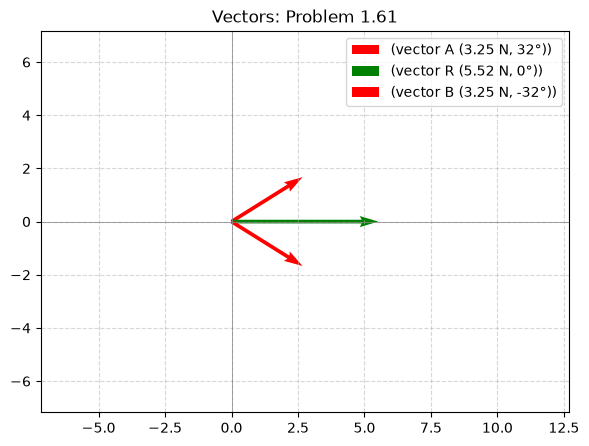

In [47]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# Plot vectors

vec_a = plot_vector(
    3.15,
    32,
    ax=ax,
    color="r",
    label="(vector A (3.25 N, 32°))",
)

vec_b = plot_vector_xy(
    R.x,
    R.y,
    ax=ax,
    color="g",
    label="(vector R (5.52 N, 0°))",
)

vec_r = plot_vector(
    3.15,
    -32,
    ax=ax,
    color="r",
    label="(vector B (3.25 N, -32°))",
)


plt.title("Vectors: Problem 1.61")


plt.tight_layout()
plt.show()

#### 1.62 

page 58

<img src="..//pics/Fig_P1_62.png" width=300> 


••• On a training flight in
Switzerland, a student pilot flies from
Bern to Zurich, next to Lugano, and
then to Sion (Fig. P1.62). The directions
are shown relative to north: 0°
is north, 90° is east, 180° is south, and
270° is west. Use the method of components
to find 

**(a)** the distance she has
to fly from Sion to get back to Bern,
and 

**(b)** the direction (relative to north)
she must fly to get there. Illustrate
your solutions with a vector diagram.

In [21]:
# Legs of the journey
l_1_mag = 101  # km
l_1_bearing_deg = 52
l_1_math_deg = math_bearing(l_1_bearing_deg)
l_1_angle = vp.radians(l_1_math_deg)
l_1 = vp.vec(l_1_mag * vp.cos(l_1_angle), l_1_mag * vp.sin(l_1_angle), 0)

l_2_mag = 165  # km
l_2_bearing_deg = 170
l_2_math_deg = math_bearing(l_2_bearing_deg)
l_2_angle = vp.radians(l_2_math_deg)
l_2 = vp.vec(l_2_mag * vp.cos(l_2_angle), l_2_mag * vp.sin(l_2_angle), 0)

l_3_mag = 124  # km
l_3_bearing_deg = 282
l_3_math_deg = math_bearing(l_3_bearing_deg)
l_3_angle = vp.radians(l_3_math_deg)
l_3 = vp.vec(l_3_mag * vp.cos(l_3_angle), l_3_mag * vp.sin(l_3_angle), 0)


# Displacement at leg 3
d_3 = l_1 + l_2 + l_3

l_4 = -d_3

# calculate magnitud and direction of l_4
l_4_mag = l_4.mag
l_4_angle = vp.degrees(vp.atan2(l_4.y, l_4.x)) % 360
l_4_bearing = math_bearing(l_4_angle)

print("Navigational vector (bearing)")
print(f"Vector l_4 = <{l_4_mag:.0f} km, {l_4_bearing:.1f}°>")

# Check the result
print("\nCheck the result:")
print(f"l_1 + l_2 + l_3 + l_4 = {l_1 + l_2 + l_3 + l_4}")

Navigational vector (bearing)
Vector l_4 = <76 km, 9.9°>

Check the result:
l_1 + l_2 + l_3 + l_4 = <0, 0, 0>


##### Ploting the Result

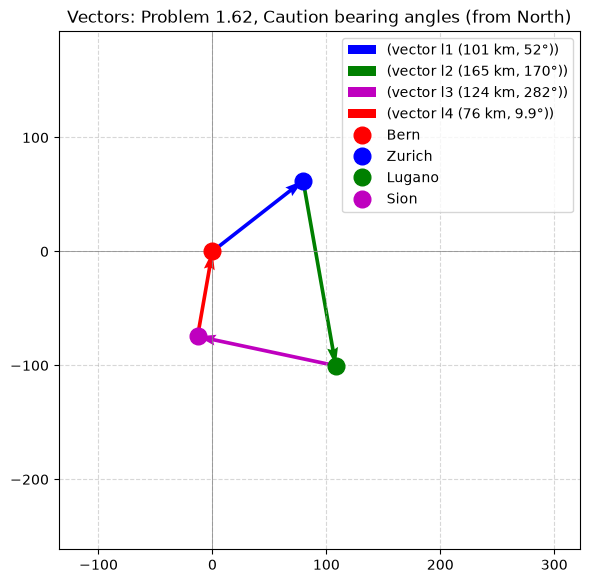

In [ ]:
# NB: Run the previous cell because some values
# are taken from it.

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# Plot vectors
vec_l1 = plot_vector_xy(
    l_1.x, l_1.y, ax=ax, color="b", label="(vector l1 (101 km, 52°))"
)
vec_l2 = plot_vector_xy(
    l_2.x,
    l_2.y,
    origin=(l_1.x, l_1.y),
    ax=ax,
    color="g",
    label="(vector l2 (165 km, 170°))",
)
vec_l3 = plot_vector_xy(
    l_3.x,
    l_3.y,
    origin=((l_1 + l_2).x, (l_1 + l_2).y),
    ax=ax,
    color="m",
    label="(vector l3 (124 km, 282°))",
)
vec_l4 = plot_vector_xy(
    l_4.x,
    l_4.y,
    origin=((l_1 + l_2 + l_3).x, (l_1 + l_2 + l_3).y),
    ax=ax,
    color="r",
    label="(vector l4 (76 km, 9.9°))",
)


# --- Add a red asterisk at point (x=0, y=0) ---
ax.plot(0, 0, "ro", markersize=12, label="Bern")
ax.plot(l_1.x, l_1.y, "bo", markersize=12, label="Zurich")
ax.plot((l_1 + l_2).x, (l_1 + l_2).y, "go", markersize=12, label="Lugano")
ax.plot((l_1 + l_2 + l_3).x, (l_1 + l_2 + l_3).y, "mo", markersize=12, label="Sion")


ax.legend()
plt.title("Vectors: Problem 1.62, Caution bearing angles (from North)")


plt.tight_layout()
plt.show()

#### 1.63 

•• You leave the airport in Wagga Wagga and fly 23.0 km in a
direction 34.0°south of east. You then fly 46.0 km due north. How far
and in what direction must you then fly to reach a private landing strip
that is 32.0 km due west of the Wagga Wagga airport?

In [ ]:
# Legs of the journey
l_1_mag = 23.0  # km
l_1_angle = vp.radians(360 - 34.0)
l_1 = vp.vec(l_1_mag * vp.cos(l_1_angle), l_1_mag * vp.sin(l_1_angle), 0)
l_2 = vp.vec(0, 46.0, 0)

# Displacement vector d
d = l_1 + l_2
# target
target = vp.vec(-32.0, 0, 0)

# calculate leg 3
l_3 = target - d
# calculate magnitud and direction of l_3
l_3_mag = l_3.mag
l_3_angle = vp.degrees(vp.atan2(l_3.y, l_3.x)) % 360
l_3_bearing = math_bearing(l_3_angle)

print("Navigational vector (bearing)")
print(f"Vector l_3 = <{l_3_mag:.1f} km, {l_3_bearing:.1f}°>")

# Check the result
print("\nCheck the result: (Sum of 3 legs = target)")
print(f"l_1 + l_2 + l_3 = {l_1 + l_2 + l_3}")

Navigational vector (bearing)
Vector l_3 = <60.9 km, 237.0°>

Check the result: (Sum of 3 legs = target)
l_1 + l_2 + l_3 = <-32, 0, 0>


##### Ploting the Result

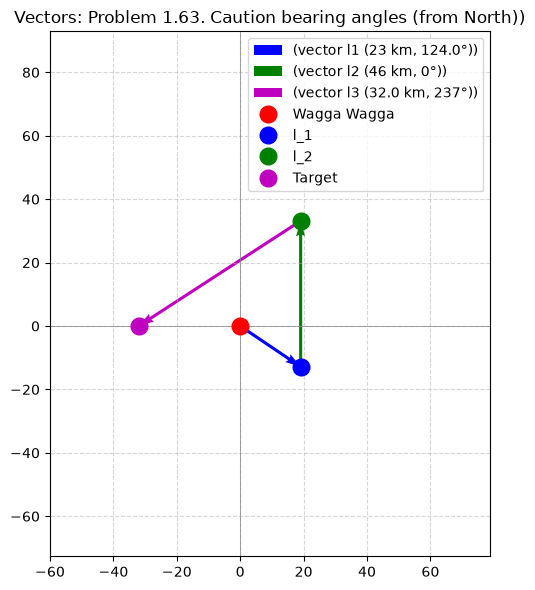

In [ ]:
# NB: Run the previous cell because some values
# are taken from it.

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# Plot vectors
vec_l1 = plot_vector(
    23.0,
    360 - 34.0,
    ax=ax,
    color="b",
    label="(vector l1 (23 km, 124.0°))",
)

vec_l2 = plot_vector_xy(
    0,
    46,
    origin=((l_1).x, (l_1).y),
    ax=ax,
    color="g",
    label="(vector l2 (46 km, 0°))",
)

vec_l3 = plot_vector_xy(
    l_3.x,
    l_3.y,
    origin=((l_1 + l_2).x, (l_1 + l_2).y),
    ax=ax,
    color="m",
    label="(vector l3 (32.0 km, 237°))",
)


# --- Add a red asterisk at point (x=0, y=0) ---
ax.plot(0, 0, "ro", markersize=12, label="Wagga Wagga")
ax.plot(l_1.x, l_1.y, "bo", markersize=12, label="l_1")
ax.plot((l_1 + l_2).x, (l_1 + l_2).y, "go", markersize=12, label="l_2")
ax.plot((l_1 + l_2 + l_3).x, (l_1 + l_2 + l_3).y, "mo", markersize=12, label="Target")


ax.legend()
plt.title("Vectors: Problem 1.63. Caution bearing angles (from North))")


plt.tight_layout()
plt.show()

#### 1.64 

••• Getting Back. 

An explorer in Antarctica leaves his shelter
during a whiteout. He takes 43 steps northeast, next 80 steps at 60°
north of west, and then 52 steps due south. Assume all of his steps are
equal in length. 

**(a)** Sketch, roughly to scale, the three vectors and their
resultant. 

**(b)** Save the explorer from becoming hopelessly lost by giving
him the displacement, calculated by using the method of components,
that will return him to his shelter.

In [ ]:
# Legs of the journey
l_1_mag = 43  # steps
l_1_angle = vp.radians(45)  # northeast
l_1 = vp.vec(l_1_mag * vp.cos(l_1_angle), l_1_mag * vp.sin(l_1_angle), 0)

l_2_mag = 80  # steps
l_2_angle = vp.radians(180 - 60)
l_2 = vp.vec(l_2_mag * vp.cos(l_2_angle), l_2_mag * vp.sin(l_2_angle), 0)

l_3 = vp.vec(0, -52, 0)  # 52 steps to south

# resultant
r = l_1 + l_2 + l_3

# return to shelter
d = -r

# calculate the return displacement, d
# calculate magnitud and direction of d
d_mag = d.mag
d_angle = vp.degrees(vp.atan2(d.y, d.x)) % 360
d_bearing = math_bearing(d_angle)

print("Navigational vector (bearing)")
print(f"Vector d = <{d_mag:.1f} steps, {d_bearing:.1f}°>")

# Check the result
print("\nCheck the result: (Sum of 3 legs + d = shelter<0,0,0>)")
print(f"l_1 + l_2 + l_3 + d = {l_1 + l_2 + l_3 + d}")

Navigational vector (bearing)
Vector d = <48.6 steps, 168.6°>

Check the result: (Sum of 3 legs + d = shelter<0,0,0>)
l_1 + l_2 + l_3 + d = <0, 0, 0>


##### Ploting the Result

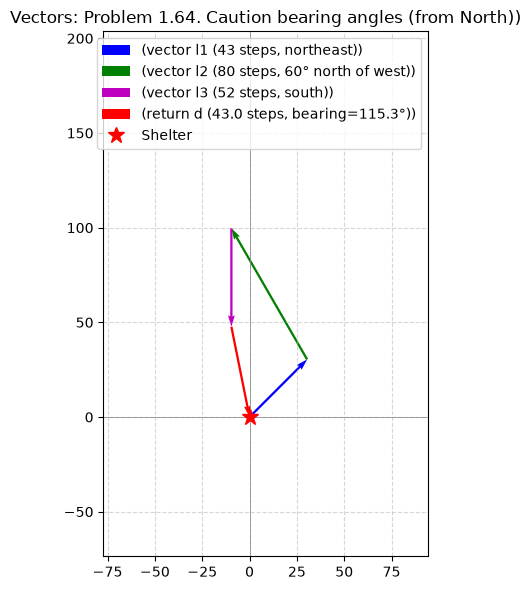

In [ ]:
# NB: Run the previous cell because some values
# are taken from it.

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# Plot vectors
vec_l1 = plot_vector_xy(
    l_1.x,
    l_1.y,
    ax=ax,
    color="b",
    label="(vector l1 (43 steps, northeast))",
)

vec_l2 = plot_vector_xy(
    l_2.x,
    l_2.y,
    origin=((l_1).x, (l_1).y),
    ax=ax,
    color="g",
    label="(vector l2 (80 steps, 60° north of west))",
)

vec_l3 = plot_vector_xy(
    l_3.x,
    l_3.y,
    origin=((l_1 + l_2).x, (l_1 + l_2).y),
    ax=ax,
    color="m",
    label="(vector l3 (52 steps, south))",
)

vec_d = plot_vector_xy(
    d.x,
    d.y,
    origin=((l_1 + l_2 + l_3).x, (l_1 + l_2 + l_3).y),
    ax=ax,
    color="aqua",
    label="(return d (43.0 steps, bearing=115.3°))",
)


# --- Add a red asterisk at point (x=0, y=0) ---
ax.plot(0, 0, "r*", markersize=12, label="Shelter")
# ax.plot(l_1.x, l_1.y, "bo", markersize=12, label="l_1")
# ax.plot((l_1 + l_2).x, (l_1 + l_2).y, "go", markersize=12, label="l_2")
# ax.plot((l_1 + l_2 + l_3).x, (l_1 + l_2 + l_3).y, "mo", markersize=12, label="l_3")


ax.legend()
plt.title("Vectors: Problem 1.64. Caution bearing angles (from North))")

# --- Move legend below the plot ---
# ax.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', framealpha=0.9, ncol=1)
# # Expand figure bounds so the outside legend isn't cut off
# plt.tight_layout()


plt.tight_layout()
plt.show()

#### 1.66 

• You are standing on a street corner with your friend. You then
travel 14.0 m due west across the street and into your apartment building.
You travel in the lift 22.0 m upward to your floor, walk 12.0 m
north to the door of your apartment, and then walk 6.0 m due east to
your balcony that overlooks the street. Your friend is standing where
you left her. Now how far are you from your friend?

In [47]:
# Legs of the journey
l_1 = vp.vec(-14.0, 0, 0)
l_2 = vp.vec(0, 0, 22.0)
l_3 = vp.vec(0, 12.0, 0)
l_4 = vp.vec(6, 0, 0)

d = l_1 + l_2 + l_3 + l_4
d.mag
print(f"Displacement mag = {d.mag:.1f} m.")

Displacement mag = 26.3 m.


#### 3D plot in Vpython
Simulation in 3D

$ vPython_P_1_66.py

#### 1.67 

•• You are lost at night in a large, open field. Your GPS tells you
that you are 122.0 m from your car, in a direction 58.0° east of south.
You walk 72.0 m due west along a ditch. How much farther, and in what
direction, must you walk to reach your car?

In [82]:
# Legs of the journey
l_1_mag = 122.0  # m
l_1_angle = vp.radians(270 + 58.0)
l_1 = vp.vec(l_1_mag * vp.cos(l_1_angle), l_1_mag * vp.sin(l_1_angle), 0)

l_2 = vp.vec(-72, 0, 0)

# resultant
r = l_1 + l_2

# return to car
d = -r

# calculate the return displacement, d
# calculate magnitud and direction of d
d_mag = d.mag
d_angle = vp.degrees(vp.atan2(d.y, d.x)) % 360
d_bearing = math_bearing(d_angle)

print("Navigational vector (bearing)")
print(f"Vector d = <{d_mag:.1f} m., {d_bearing:.1f}°>")

# Check the result
print("\nCheck the result: (Sum of 3 legs + d = shelter<0,0,0>)")
print(f"l_1 + l_2 + d = {l_1 + l_2 + d}")

Navigational vector (bearing)
Vector d = <71.9 m., 334.1°>

Check the result: (Sum of 3 legs + d = shelter<0,0,0>)
l_1 + l_2 + d = <0, 0, 0>


##### Ploting the Result

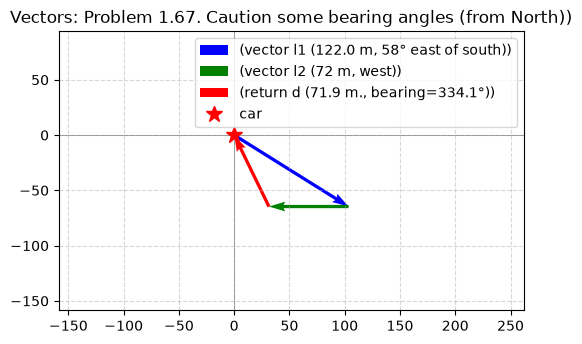

In [83]:
# NB: Run the previous cell because some values
# are taken from it.

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# Plot vectors
vec_l1 = plot_vector_xy(
    l_1.x,
    l_1.y,
    ax=ax,
    color="b",
    label="(vector l1 (122.0 m, 58° east of south))",
)

vec_l2 = plot_vector_xy(
    l_2.x,
    l_2.y,
    origin=((l_1).x, (l_1).y),
    ax=ax,
    color="g",
    label="(vector l2 (72 m, west))",
)


vec_d = plot_vector_xy(
    d.x,
    d.y,
    origin=((l_1 + l_2).x, (l_1 + l_2).y),
    ax=ax,
    color="r",
    label="(return d (71.9 m., bearing=334.1°))",
)


# --- Add a red asterisk at point (x=0, y=0) ---
ax.plot(0, 0, "r*", markersize=12, label="car")
# ax.plot(l_1.x, l_1.y, "bo", markersize=12, label="l_1")
# ax.plot((l_1 + l_2).x, (l_1 + l_2).y, "go", markersize=12, label="l_2")


ax.legend()
plt.title("Vectors: Problem 1.67. Caution some bearing angles (from North))")

# --- Move legend below the plot ---
# ax.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', framealpha=0.9, ncol=1)
# # Expand figure bounds so the outside legend isn't cut off
# plt.tight_layout()

plt.show()

#### 1.68 

••• You live in a town where the streets are straight but are in a
variety of directions. On Saturday you go from your apartment to the
grocery store by driving 0.60 km due north and then 1.40 km in the
direction 60.0° west of north. On Sunday you again travel from your
apartment to the same store but this time by driving 0.80 km in the
direction 50.0° north of west and then in a straight line to the store.

**(a)** How far is the store from your apartment? 

**(b)** On which day do you
travel the greater distance, and how much farther do you travel? Or, do
you travel the same distance on each route to the store?

In [ ]:
# Saturday journey
Sat_1 = vp.vec(0, 0.60, 0)  #  0.60 km due north
Sat_2_mag = 1.40  # km
Sat_2_angle = vp.radians(90 + 60)  # 1.40 km direction 60.0° west of north
Sat_2 = vp.vec(Sat_2_mag * vp.cos(Sat_2_angle), Sat_2_mag * vp.sin(Sat_2_angle), 0)
Store = Sat_1 + Sat_2

# Sunday journey
Sun_1_mag = 0.80  # km
Sun_1_angle = vp.radians(180 - 50)  #  0.80 km direction 50.0° north of west
Sun_1 = vp.vec(Sun_1_mag * vp.cos(Sun_1_angle), Sun_1_mag * vp.sin(Sun_1_angle), 0)
# Sun_1 + Sun_2 = Store ==> Sun_2 = Store - Sun_1
Sun_2 = Store - Sun_1

print("(a)")
Distance = Store.mag
print(f"Displacement to store = {Store.mag:.2f} km")

print()
print("(b)")
Distance_sat = Sat_1.mag + Sat_2.mag
print(f"Distance travel on Saturday = {Distance_sat:.2f} km")

Distance_sun = Sun_1.mag + Sun_2.mag
print(f"Distance travel on Sunday = {Distance_sun:.2f} km")

delta_Distance = Distance_sat - Distance_sun
print(f"Difference: {delta_Distance:.2f} km (Saturday is farther)")


(a)
Displacement to store = 1.78 km

(b)
Distance travel on Saturday = 2.00 km
Distance travel on Sunday = 1.78 km
Difference: 0.22 km (Saturday is farther)


##### Ploting the Result

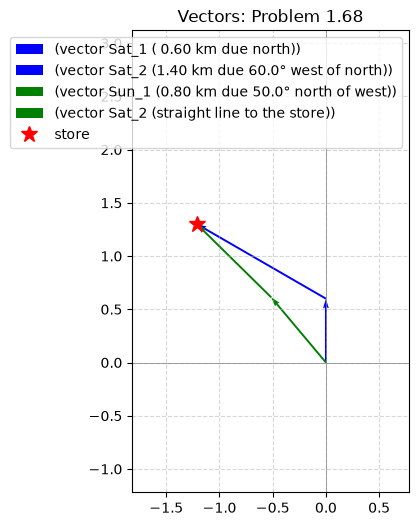

In [ ]:
# NB: Run the previous cell because some values
# are taken from it.

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# Plot vectors
# Saturday journey
vec_sat_1 = plot_vector_xy(
    Sat_1.x,
    Sat_1.y,
    ax=ax,
    color="b",
    label="(vector Sat_1 ( 0.60 km due north))",
)

vec_sat_2 = plot_vector_xy(
    Sat_2.x,
    Sat_2.y,
    origin=((Sat_1).x, (Sat_1).y),
    ax=ax,
    color="b",
    label="(vector Sat_2 (1.40 km due 60.0° west of north))",
)

# Sunday journey
vec_sun_1 = plot_vector_xy(
    Sun_1.x,
    Sun_1.y,
    ax=ax,
    color="g",
    label="(vector Sun_1 (0.80 km due 50.0° north of west))",
)

vec_sun_2 = plot_vector_xy(
    Sun_2.x,
    Sun_2.y,
    origin=((Sun_1).x, (Sun_1).y),
    ax=ax,
    color="g",
    label="(vector Sat_2 (straight line to the store))",
)


# --- Add a red asterisk at the store ---
ax.plot(Store.x, Store.y, "r*", markersize=12, label="store")


ax.legend()
plt.title("Vectors: Problem 1.68")

# --- Move legend below the plot ---
# ax.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', framealpha=0.9, ncol=1)
# # Expand figure bounds so the outside legend isn't cut off
# plt.tight_layout()

plt.show()

#### 1.70 
•• A fence post is 59.0 m from where you are standing, in a direction
38.0° north of east. A second fence post is due south from you.
How far are you from the second post if the distance between the two
posts is 70.0 m?

In [40]:
# --- 1. Define Vector Inputs ---
r1 = 59.0  # Distance to first post (m)
theta_deg = 38.0  # Angle North of East
D = 70.0  # Distance between posts (m)

# First Post Position Vector (P1)
p1_x = r1 * np.cos(np.radians(theta_deg))
p1_y = r1 * np.sin(np.radians(theta_deg))
P1 = vp.vec(p1_x, p1_y, 0)

# Calculate distance d to second post from origin, using Pythagorean theorem:
# (P1.x - 0)^2 + (P1.y - (-d))^2 = D^2
d = np.sqrt(D**2 - P1.x**2) - P1.y

# Second Post Position Vector (P2)
P2 = vp.vec(0, -d, 0)

# Vector from Post 1 to Post 2
P1_to_P2 = P2 - P1

# --- Print Result ---
print(f"Distance to second post: {d:.1f} m")

# --- Check Result ---
print()
print("Check Result:")
print(f"Distance from P1 to P2: {P1_to_P2.mag:.1f} m")

Distance to second post: 16.0 m

Check Result:
Distance from P1 to P2: 70.0 m


##### Ploting the Result

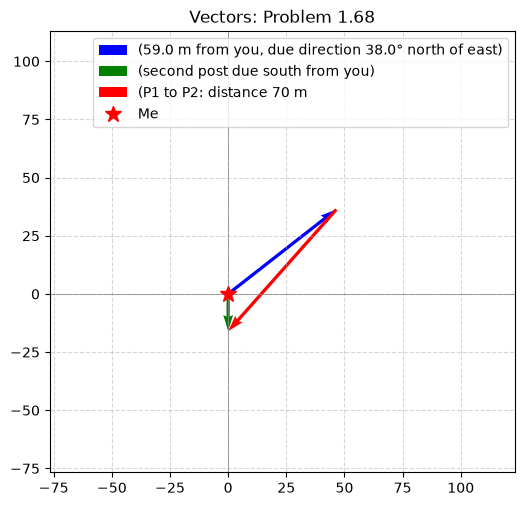

In [ ]:
# NB: Run the previous cell because some values
# are taken from it.

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# Plot vectors
# Me at origin, P_1 to first post
vec_P1 = plot_vector_xy(
    P1.x,
    P1.y,
    ax=ax,
    color="b",
    label="(59.0 m from you, due direction 38.0° north of east)",
)

vec_P2 = plot_vector_xy(
    P2.x,
    P2.y,
    ax=ax,
    color="g",
    label="(second post due south from you)",
)

vec_P1_to_P2 = plot_vector_xy(
    P1_to_P2.x,
    P1_to_P2.y,
    origin=(P1.x, P1.y),
    ax=ax,
    color="r",
    label="(P1 to P2: distance 70 m",
)

# --- Add a red asterisk at the store ---
ax.plot(0, 0, "r*", markersize=12, label="Me")


ax.legend()
plt.title("Vectors: Problem 1.68")

# --- Move legend below the plot ---
# ax.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', framealpha=0.9, ncol=1)
# # Expand figure bounds so the outside legend isn't cut off
# plt.tight_layout()

plt.show()